In [1]:
# Data anaysis
import pandas as pd
import numpy as np

# Plotting and Correlation Maths
import seaborn as sns
import scipy as sci

# Simple model development
import sklearn as sk
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree

# Plotting
import matplotlib.pyplot as plt
import plotly as px

# Pathing (maybe should use PATH in the future?)
import os

In [2]:
# get data
data = pd.read_csv('../data/processed/cleaned_data_survive.csv')
data

,date,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,2018-01-07,26.2,-4.2,10.1,18.1,-16.6,0.6,-3.8,57.2,0.000,...,0,0,0,1,0,0,0,0,0,0
1,2018-01-09,35.8,28.0,32.5,34.7,24.1,26.8,26.6,78.9,0.000,...,0,0,0,1,0,0,0,0,0,0
2,2018-01-14,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,...,0,0,0,1,0,0,0,0,0,0
3,2018-01-14,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,...,0,0,0,1,0,0,0,0,0,0
4,2018-01-14,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3481,2024-04-08,73.0,49.3,60.1,73.0,47.3,60.0,37.1,42.8,0.006,...,0,0,0,0,1,0,0,0,0,0
3482,2024-04-10,65.1,57.1,60.6,65.1,57.1,60.6,54.5,80.9,0.179,...,0,0,0,0,1,0,0,0,0,0
3483,2024-04-12,59.4,46.8,50.8,59.4,39.8,46.5,46.3,84.5,0.266,...,0,0,0,0,1,0,0,0,0,0
3484,2024-04-13,59.2,44.5,51.1,59.2,37.4,47.9,33.0,51.5,0.019,...,0,0,0,0,1,0,0,0,0,0


In [3]:
# I kept the data in the .csv so that we could use it if we needed it
#  For things like the Year
data = data.drop('date', axis=1)
data

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,26.2,-4.2,10.1,18.1,-16.6,0.6,-3.8,57.2,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
1,35.8,28.0,32.5,34.7,24.1,26.8,26.6,78.9,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
2,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
3,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
4,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3481,73.0,49.3,60.1,73.0,47.3,60.0,37.1,42.8,0.006,8.33,...,0,0,0,0,1,0,0,0,0,0
3482,65.1,57.1,60.6,65.1,57.1,60.6,54.5,80.9,0.179,62.50,...,0,0,0,0,1,0,0,0,0,0
3483,59.4,46.8,50.8,59.4,39.8,46.5,46.3,84.5,0.266,83.33,...,0,0,0,0,1,0,0,0,0,0
3484,59.2,44.5,51.1,59.2,37.4,47.9,33.0,51.5,0.019,12.50,...,0,0,0,0,1,0,0,0,0,0


In [4]:
# Split the inputs and targets

target = data['survive'].copy()
inputs = data.drop('survive', axis=1).copy()

In [5]:
inputs

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,26.2,-4.2,10.1,18.1,-16.6,0.6,-3.8,57.2,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
1,35.8,28.0,32.5,34.7,24.1,26.8,26.6,78.9,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
2,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
3,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
4,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3481,73.0,49.3,60.1,73.0,47.3,60.0,37.1,42.8,0.006,8.33,...,0,0,0,0,1,0,0,0,0,0
3482,65.1,57.1,60.6,65.1,57.1,60.6,54.5,80.9,0.179,62.50,...,0,0,0,0,1,0,0,0,0,0
3483,59.4,46.8,50.8,59.4,39.8,46.5,46.3,84.5,0.266,83.33,...,0,0,0,0,1,0,0,0,0,0
3484,59.2,44.5,51.1,59.2,37.4,47.9,33.0,51.5,0.019,12.50,...,0,0,0,0,1,0,0,0,0,0


# Compute the SVD

Variance cutoff can be done around 15-17 features.  The plot shows the intersection at 95% variance and 16 S values.

This will allow us to drop around 10 features and still have reasonable outputs from the model.

In [6]:
# This will center and scale the dataset for PCA
scaler = StandardScaler()
scaled_inputs = scaler.fit_transform(inputs)
# Remake a DF so we can see the described data to ensure the scaler worked
scaled_inputs_df = pd.DataFrame(scaled_inputs, columns=inputs.columns)
scaled_inputs_df

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,-2.062404,-3.147538,-2.672183,-2.189466,-3.044612,-2.655105,-2.749051,-0.873388,-0.431849,-0.714752,...,-0.04796,-0.050877,-0.033893,1.291983,-0.954011,-0.058773,-0.033893,-0.338305,-0.041523,-0.187178
1,-1.524948,-1.154972,-1.327604,-1.364271,-0.975779,-1.314065,-0.985648,0.692902,-0.431849,-0.714752,...,-0.04796,-0.050877,-0.033893,1.291983,-0.954011,-0.058773,-0.033893,-0.338305,-0.041523,-0.187178
2,-2.672640,-2.732936,-2.726207,-2.363453,-2.505801,-2.506669,-2.499622,-0.093852,-0.431849,-0.714752,...,-0.04796,-0.050877,-0.033893,1.291983,-0.954011,-0.058773,-0.033893,-0.338305,-0.041523,-0.187178
3,-2.672640,-2.732936,-2.726207,-2.363453,-2.505801,-2.506669,-2.499622,-0.093852,-0.431849,-0.714752,...,-0.04796,-0.050877,-0.033893,1.291983,-0.954011,-0.058773,-0.033893,-0.338305,-0.041523,-0.187178
4,-2.672640,-2.732936,-2.726207,-2.363453,-2.505801,-2.506669,-2.499622,-0.093852,-0.431849,-0.714752,...,-0.04796,-0.050877,-0.033893,1.291983,-0.954011,-0.058773,-0.033893,-0.338305,-0.041523,-0.187178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3481,0.557695,0.163092,0.329109,0.539643,0.203506,0.385267,-0.376578,-1.912769,-0.411628,-0.330251,...,-0.04796,-0.050877,-0.033893,-0.774004,1.048206,-0.058773,-0.033893,-0.338305,-0.041523,-0.187178
3482,0.115413,0.645763,0.359122,0.146930,0.701652,0.415978,0.632739,0.837261,0.171430,2.170156,...,-0.04796,-0.050877,-0.033893,-0.774004,1.048206,-0.058773,-0.033893,-0.338305,-0.041523,-0.187178
3483,-0.203701,0.008389,-0.229131,-0.136420,-0.177729,-0.305727,0.157084,1.097106,0.464643,3.131639,...,-0.04796,-0.050877,-0.033893,-0.774004,1.048206,-0.058773,-0.033893,-0.338305,-0.041523,-0.187178
3484,-0.214898,-0.133937,-0.211124,-0.146362,-0.299724,-0.234068,-0.614405,-1.284810,-0.367814,-0.137770,...,-0.04796,-0.050877,-0.033893,-0.774004,1.048206,-0.058773,-0.033893,-0.338305,-0.041523,-0.187178


In [7]:
# Check for centering (mean = 0) and standardization
scaled_inputs_df.describe()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
count,3.486000e+03,3.486000e+03,3.486000e+03,3.486000e+03,3486.000000,3.486000e+03,3.486000e+03,3.486000e+03,3.486000e+03,3.486000e+03,...,3.486000e+03,3486.000000,3.486000e+03,3.486000e+03,3.486000e+03,3.486000e+03,3.486000e+03,3.486000e+03,3.486000e+03,3.486000e+03
mean,-7.337791e-17,-2.853585e-16,-1.956744e-16,3.261240e-17,0.000000,-8.153101e-17,-2.935116e-16,1.793682e-16,4.076550e-18,1.426793e-16,...,-3.261240e-17,0.000000,-1.019138e-17,8.153101e-18,-9.987548e-17,-8.153101e-18,-2.038275e-18,-4.891860e-17,8.153101e-18,7.337791e-17
std,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,...,1.000143e+00,1.000143,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00,1.000143e+00
min,-2.890982e+00,-3.197043e+00,-3.050346e+00,-2.955009e+00,-3.746083,-3.361453e+00,-2.940473e+00,-3.125381e+00,-4.318493e-01,-7.147516e-01,...,-4.796011e-02,-0.050877,-3.389344e-02,-7.740042e-01,-9.540110e-01,-5.877271e-02,-3.389344e-02,-3.383048e-01,-4.152274e-02,-1.871781e-01
25%,-8.195365e-01,-8.579438e-01,-8.518995e-01,-8.472812e-01,-0.872846,-8.585214e-01,-8.406310e-01,-6.712858e-01,-4.318493e-01,-7.147516e-01,...,-4.796011e-02,-0.050877,-3.389344e-02,-7.740042e-01,-9.540110e-01,-5.877271e-02,-3.389344e-02,-3.383048e-01,-4.152274e-02,-1.871781e-01
50%,1.993908e-01,4.551781e-02,8.300304e-02,2.214958e-01,0.096760,1.702912e-01,3.236959e-02,8.659648e-02,-4.149979e-01,-5.222705e-01,...,-4.796011e-02,-0.050877,-3.389344e-02,-7.740042e-01,-9.540110e-01,-5.877271e-02,-3.389344e-02,-3.383048e-01,-4.152274e-02,-1.871781e-01
75%,8.712110e-01,9.304152e-01,9.113597e-01,8.180224e-01,0.935476,8.855974e-01,9.111708e-01,7.506457e-01,-5.437876e-02,4.392116e-01,...,-4.796011e-02,-0.050877,-3.389344e-02,1.291983e+00,1.048206e+00,-5.877271e-02,-3.389344e-02,-3.383048e-01,-4.152274e-02,-1.871781e-01
max,1.716585e+00,1.784372e+00,1.721709e+00,1.911655e+00,1.636948,1.777491e+00,1.792872e+00,2.158141e+00,1.278636e+01,3.901101e+00,...,2.085066e+01,19.655364,2.950424e+01,1.291983e+00,1.048206e+00,1.701470e+01,2.950424e+01,2.955914e+00,2.408319e+01,5.342506e+00


In [8]:
# Change the number of singular value components to see how much variance you'll be keeping
#  Max is 26; 15 gives us just under 95%.
n_comps = 9

# Create a PCA class and fit the model
pca = PCA(n_components=n_comps, svd_solver='full')
pca.fit(scaled_inputs)
# Transform via the PCA
inputs_pca = pca.transform(scaled_inputs)

In [9]:
inputs_pca.shape

(3486, 9)

In [10]:
sum(pca.explained_variance_ratio_)

0.7648197860779881

In [11]:
ratios = pca.explained_variance_ratio_
ratios

array([0.31196296, 0.15023035, 0.05330173, 0.04866516, 0.04389201,
       0.04013707, 0.03913016, 0.03883568, 0.03866467])

In [12]:
r_values = np.cumsum(ratios**2) / sum(ratios**2)
print(r_values)

[0.73079505 0.90026975 0.92160375 0.9393876  0.953854   0.96595109
 0.97744884 0.98877418 1.        ]


<function matplotlib.pyplot.show(close=None, block=None)>

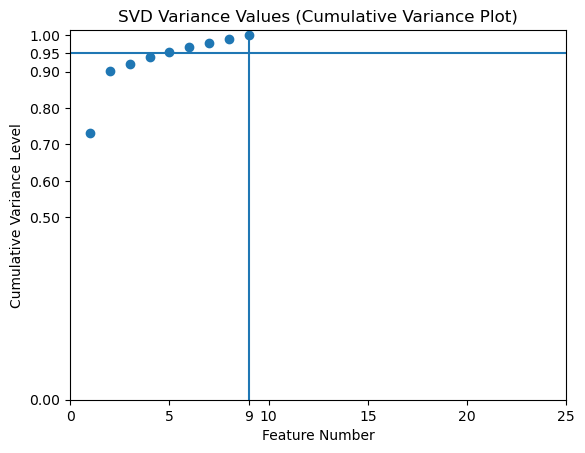

In [13]:
# Create plot; This will only make sense when n_comps = 26!
fig, ax = plt.subplots()
plt.scatter(range(1,len(r_values)+1),r_values)
plt.axhline(0.95)
plt.axvline(9)
plt.xlabel('Feature Number')
plt.ylabel('Cumulative Variance Level')
plt.title('SVD Variance Values (Cumulative Variance Plot)')

xt = [0, 5, 9, 10, 15, 20, 25]
yt = [0,  0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
plt.xticks(ticks=xt)
plt.yticks(ticks=yt)

plt.show

# Time to Create a Model

In [14]:
# Split the data
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(inputs_pca, target, test_size=0.2, random_state=42)


In [15]:
X_train.shape, X_test.shape

((2788, 9), (698, 9))

In [16]:
y_train.shape, y_test.shape

((2788,), (698,))

In [17]:
#TODO: Either one-hot encode the 'survive' feature or leave it... might depend on the model built



# Logistic Regression Model

In [18]:
# Build your model

# Logistic Regression Setup via sklearn:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.fit
log_res = LogisticRegression()
log_res.fit(X_train, y_train)
log_preds = log_res.predict(X_test) # Will give predictions for your own analysis
log_res_score = log_res.score(X_test, y_test)  # Will give mean accuracy on the test data and labels
print(log_res_score)

0.8438395415472779


In [19]:
log_preds[0:10]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

While the log_res looks ok with an accuracy of 0.84, the predictions all come out to 1, which is everyone surviving... I'm certain on further analysis (F1 score, confusion matrix) this'll show up as poor results.

# Random Forest Model

In [20]:

# Random Forest Classifier Setup via sklearn:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
rf = RandomForestClassifier(n_estimators=100, criterion='entropy') # could use 'gini'
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test) # Will give predictions for your own analysis
rf_score = log_res.score(X_test, y_test)  # Will give mean accuracy on the test data and labels
print(rf_score)


0.8438395415472779


In [21]:
rf_preds

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [22]:
len(rf.estimators_)

100

In [23]:
# TODO:
# I can't get my old code to display a decision tree to work...

from graphviz import Source
estimator = rf.estimators_[25]
tree_data = tree.export_graphviz(estimator, out_file='Tree.dot')
#Save the tree out to a pdf file
Source(tree_data)
Source(tree_data).render('tree')

AttributeError: 'NoneType' object has no attribute 'splitlines'

The RF did a slightly better job, it at least has some 0 values in it signifying deaths that happened.  More post-analysis needs to be done.

# Nerual Network Model

In [24]:

# Neural Network Setup via sklearn: (if you wanted to toss this you could use TensorFlow or PyTorch.  doesn't matter to me)
# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
nn = MLPClassifier(hidden_layer_sizes=(30,20,10), activation='relu', solver='adam', max_iter=1000)
nn.fit(X_train, y_train)
nn_preds = nn.predict(X_test) # Will give predictions for your own analysis
nn_score = log_res.score(X_test, y_test)  # Will give mean accuracy on the test data and labels
print(nn_score)

0.8438395415472779


In [25]:
nn_preds

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

Similar results to the RF... does have zeros... need more post-analysis.